In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [35]:
df = pd.read_csv("C:\\Users\\Dell\\Desktop\\1204\\AI ML prime praticel\\ml practics\\shop_smart_ecommerce\\shop_smart_ecommerce.csv")
df.head()
df.info()
df.isnull().sum()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [36]:
# preprocessing
from sklearn.preprocessing import OneHotEncoder

cat_cols = ["Month","VisitorType","Weekend"]
oha = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoderd = oha.fit_transform(df[cat_cols])
encoderd_df=pd.DataFrame(encoderd,columns=oha.get_feature_names_out(cat_cols),index=df.index)
df=pd.concat([df.drop(columns=cat_cols),encoderd_df],axis=1)


In [37]:
X = df.drop("Revenue",axis=1)
y = df["Revenue"]




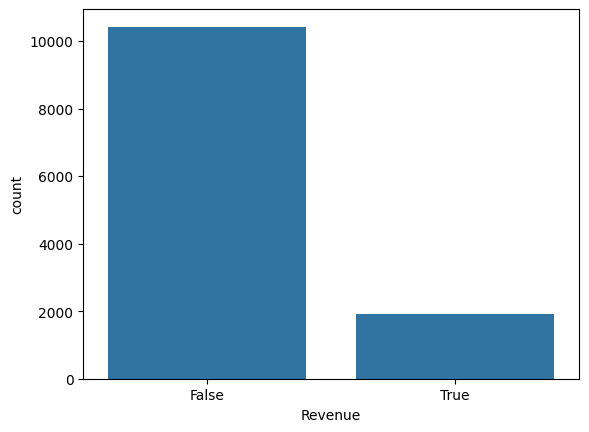

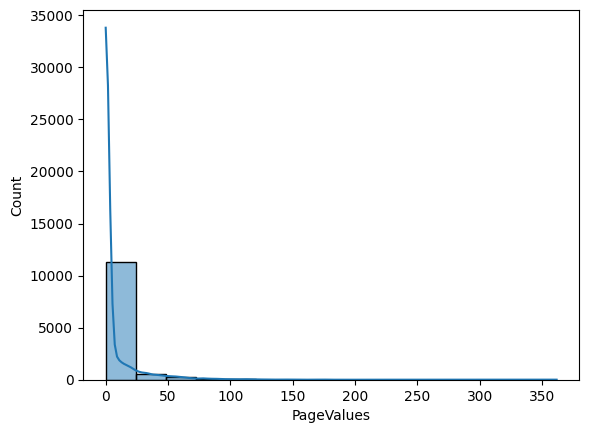

In [38]:


sns.countplot(x="Revenue", data=df)
plt.show()

sns.histplot(df["PageValues"], kde=True)
plt.show()

In [39]:
model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

In [51]:
pipline = Pipeline([
   
    ("model", model)
])

In [52]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [53]:
# Train
pipline.fit(X_train, y_train)

# Predict
y_pred = pipline.predict(X_test)

# Evaluate
print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 0.625968992248062
